# Multi-Stage Attack Detection Using Random Forest (Baseline v3.1)

## Fix dari v3:
- Stage 2 F1 anjlok karena IP-split menempatkan **semua** password & mitm di test
  (0 di train → model gak pernah lihat → classify Other)
- Train Stage 2 cuma dari **2 src_ip** → gak generalize

## Solusi: **Type-Aware IP Split**
- Untuk setiap **attack type**, pastikan ada IP di train DAN test
- Ini menjamin setiap jenis serangan terwakili di kedua set
- Baru setelah itu, volume-based whale filtering seperti v2

# SETUP

---
## 0. Imports

In [403]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support
)
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier


warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load & Prepare

In [404]:
df = pd.read_csv('train_test_network.csv')
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df['dst_port'] = pd.to_numeric(df['dst_port'], errors='coerce').fillna(0)
df['ts'] = pd.to_numeric(df['ts'], errors='coerce')

STAGE_MAP = {
    'normal': 0, 'scanning': 1,
    'xss': 2, 'ddos': 2, 'dos': 2, 'injection': 2, 'mitm': 2, 'password': 2,
    'backdoor': 3, 'ransomware': 3,
}
df['stage'] = df['type'].map(STAGE_MAP)
assert df['stage'].isna().sum() == 0

print(f"Shape: {df.shape}")
print(f"\nStage: {df['stage'].value_counts().sort_index().to_dict()}")
print(f"Types: {df['type'].value_counts().to_dict()}")


Shape: (170591, 48)

Stage: {0: 96395, 1: 23702, 2: 49469, 3: 1025}
Types: {'normal': 96395, 'scanning': 23702, 'injection': 16310, 'xss': 15231, 'dos': 14547, 'ddos': 2047, 'password': 1034, 'ransomware': 886, 'mitm': 300, 'backdoor': 139}


In [405]:
min_range = df[df['stage'] == 3]['ts'].min()
max_range = df[df['stage'] == 3]['ts'].max()

for i in df[df['stage'] == 3]:
    min_range = df[df['stage'] == 3]['ts'].min()
    max_range = df[df['stage'] == 3]['ts'].max()

    mask = (df['stage'] == 3) & (df['ts'] != min_range) & (df['ts'] != max_range)
    df.loc[mask, 'ts'] = np.random.RandomState(42).uniform(min_range, max_range, size=mask.sum())

---
### Attack Chain Analysis

In [406]:
dst_s1 = set(df[df['stage']==1]['dst_ip'].unique())
dst_s2 = set(df[df['stage']==2]['dst_ip'].unique())
dst_s3 = set(df[df['stage']==3]['dst_ip'].unique())
print(f"Dst IPs: S1={len(dst_s1)} | S2={len(dst_s2)} | S3={len(dst_s3)}")
print(f"S1∩S2={len(dst_s1&dst_s2)} | S1∩S2∩S3={len(dst_s1&dst_s2&dst_s3)}")

rows = []
for ip in sorted(dst_s1 | dst_s2 | dst_s3):
    s1=len(df[(df['dst_ip']==ip)&(df['stage']==1)])
    s2=len(df[(df['dst_ip']==ip)&(df['stage']==2)])
    s3=len(df[(df['dst_ip']==ip)&(df['stage']==3)])
    if s1>0 or s3>0: rows.append({'dst_ip':ip,'S1':s1,'S2':s2,'S3':s3})
print(f"\nKey targets:")
print(pd.DataFrame(rows).sort_values('S3',ascending=False).head(15).to_string(index=False))

Dst IPs: S1=46 | S2=161 | S3=13
S1∩S2=38 | S1∩S2∩S3=5

Key targets:
         dst_ip  S1  S2  S3
  192.168.1.193 200 128 508
   192.168.1.33 200   0 335
     121.0.0.42   0   0  49
  103.38.120.36   0  23  48
  34.230.157.88   1   9  26
    192.168.1.1 200 300  18
    13.55.50.68   0   0   9
   192.168.1.37   0   0   9
  52.11.124.117   1  14   8
  203.14.129.10   0   0   5
192.168.159.152   0  24   4
  34.236.82.205   0   5   4
    192.168.1.6   2   7   2
   192.168.1.79 200 104   0
255.255.255.255   4  24   0


In [407]:
len(df[df['stage'] == 3]['dst_ip'].unique())

13

### Check stage timestamps

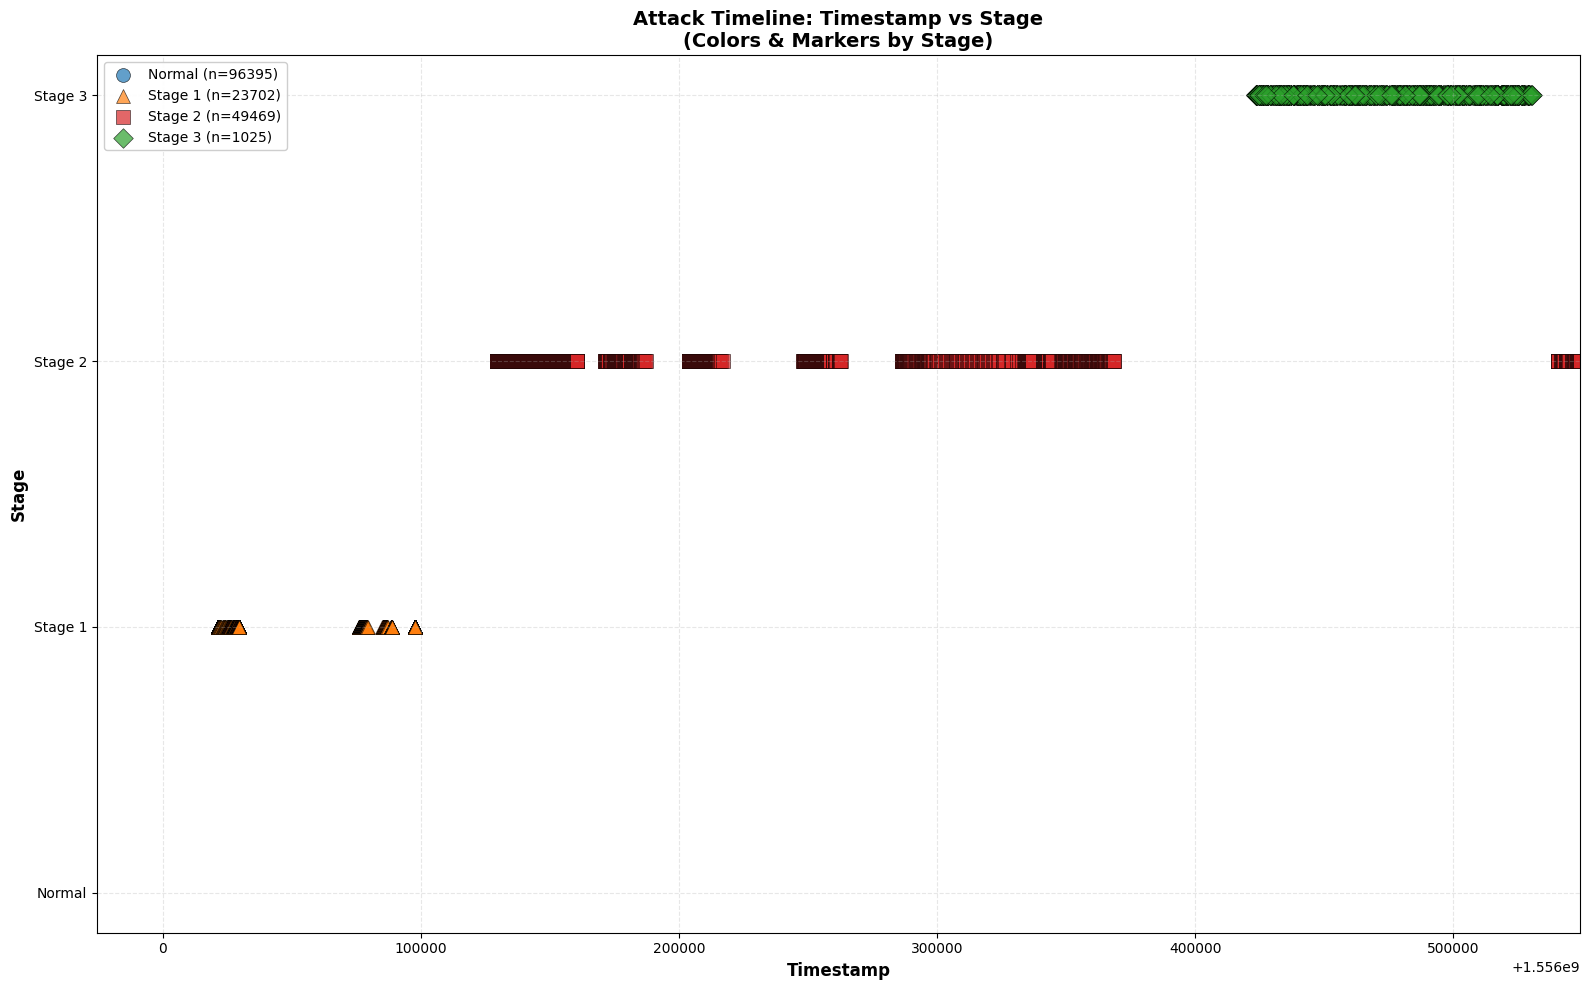


Visualization Summary:
  Total events: 170591
  Timestamp range: 1554198358 to 1556549129
  Display range: 1555974395 to 1556549129
  Stage distribution:
    Normal:  96395 ( 56.5%)
    Stage 1:  23702 ( 13.9%)
    Stage 2:  49469 ( 29.0%)
    Stage 3:   1025 (  0.6%)


In [408]:
# Temporal-Stage Dot Graph: Timestamp vs Stage (marked & colored by Stage)
df_plot = df.dropna(subset=['ts']).copy()

# Map stages to colors, markers, and names
stage_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}  # blue, orange, red, green
stage_names = {0: 'Normal', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}  # circle, triangle, square, diamond

# Find timestamp limits: start just before first non-normal stage
first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
ts_margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02  # 2% margin
ts_start = first_stage_ts - ts_margin if first_stage_ts else df_plot['ts'].min()
ts_end = df_plot['ts'].max()

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Plot each stage separately for legend
for stage in sorted(df_plot['stage'].unique()):
    stage_data = df_plot[df_plot['stage'] == stage]
    ax.scatter(stage_data['ts'], stage_data['stage'], 
               c=stage_colors[stage], 
               marker=stage_markers[stage],
               s=100, alpha=0.7, 
               label=f'{stage_names[stage]} (n={len(stage_data)})',
               edgecolors='black', linewidth=0.5)

# Configure axes
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Stage', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Stage\n(Colors & Markers by Stage)', 
             fontsize=14, fontweight='bold')

# Set Y-axis ticks and labels to stages
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([stage_names[s] for s in [0, 1, 2, 3]])

# Set X-axis limits
ax.set_xlim(ts_start, ts_end)

# Format X-axis
ax.ticklabel_format(style='plain', axis='x')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig('timeline_stage_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization Summary:")
print(f"  Total events: {len(df_plot)}")
print(f"  Timestamp range: {df_plot['ts'].min():.0f} to {df_plot['ts'].max():.0f}")
print(f"  Display range: {ts_start:.0f} to {ts_end:.0f}")
print(f"  Stage distribution:")
for s in [0, 1, 2, 3]:
    count = (df_plot['stage'] == s).sum()
    pct = 100 * count / len(df_plot)
    print(f"    {stage_names[s]}: {count:>6} ({pct:>5.1f}%)")

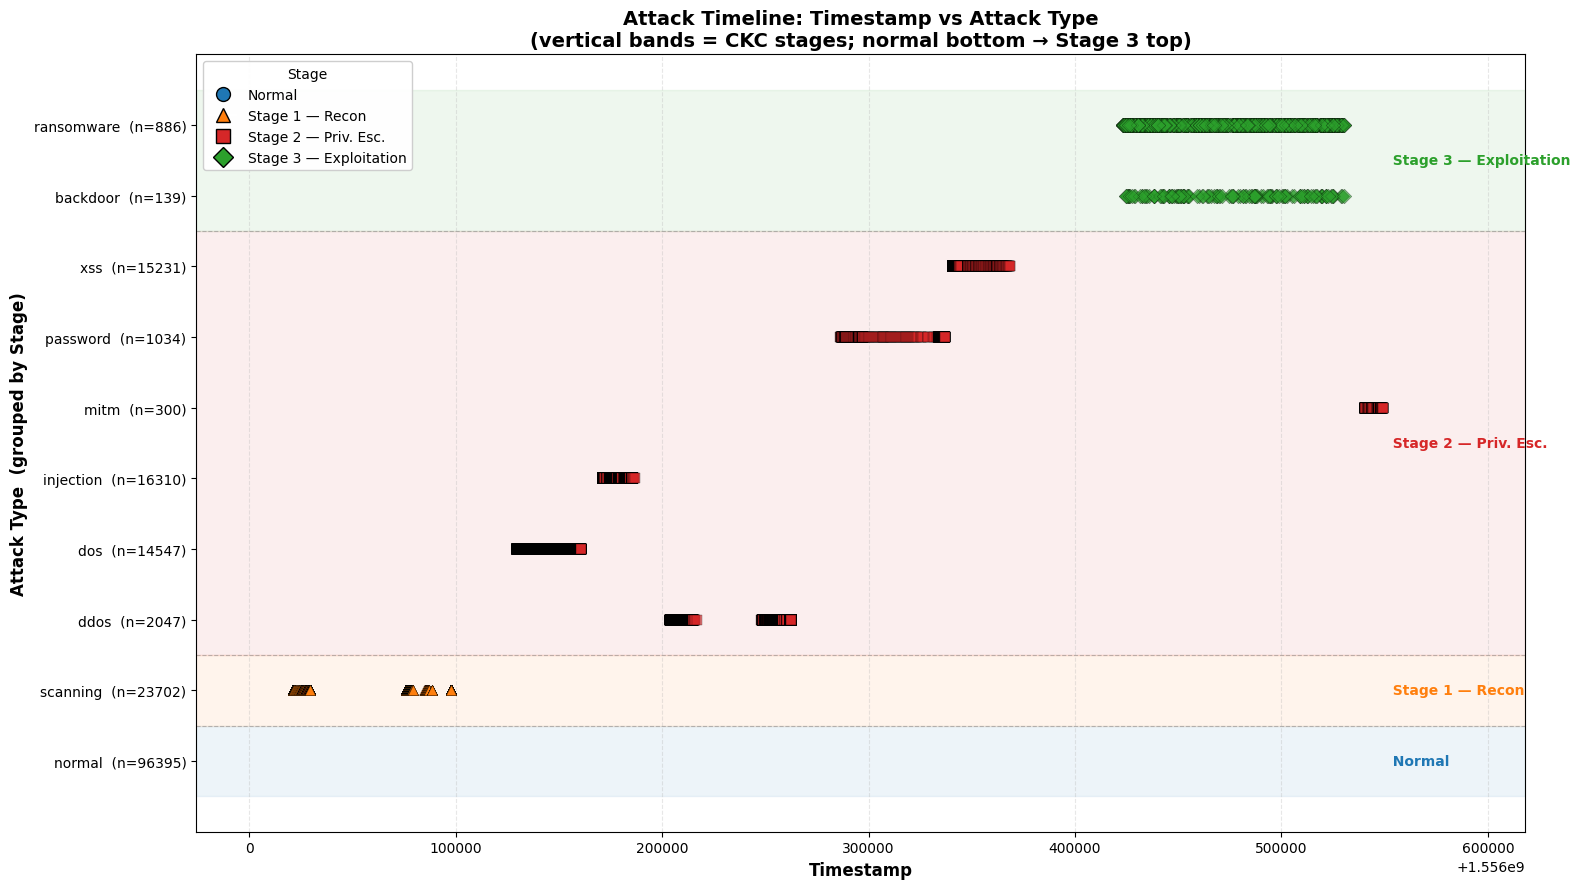

In [409]:
# Temporal-Stage Dot Graph: Timestamp vs Attack TYPE, grouped into Stage bands
df_plot = df.dropna(subset=['ts']).copy()

stage_colors  = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}
stage_names   = {0: 'Normal', 1: 'Stage 1 — Recon', 2: 'Stage 2 — Priv. Esc.', 3: 'Stage 3 — Exploitation'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}

# --- order attack types by stage (normal bottom → stage 3 top) ---
TYPE_STAGE = {t: df_plot.loc[df_plot['type'] == t, 'stage'].iloc[0] for t in df_plot['type'].unique()}
types_by_stage = {s: sorted([t for t, st in TYPE_STAGE.items() if st == s]) for s in [0, 1, 2, 3]}
y_order = []                      # bottom → top
for s in [0, 1, 2, 3]:
    y_order.extend(types_by_stage[s])
ypos = {t: i for i, t in enumerate(y_order)}

SHOW_NORMAL_CLUSTER = False       # True = include the far-left normal cluster in view

first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02
ts_start = (df_plot['ts'].min() if SHOW_NORMAL_CLUSTER
            else (first_stage_ts - margin if pd.notna(first_stage_ts) else df_plot['ts'].min()))
ts_end = df_plot['ts'].max()

fig, ax = plt.subplots(figsize=(16, 9))

# --- shaded horizontal bands per stage + right-side label + separators ---
for s in [0, 1, 2, 3]:
    ys = [ypos[t] for t in types_by_stage[s]]
    if not ys:
        continue
    lo, hi = min(ys) - 0.5, max(ys) + 0.5
    ax.axhspan(lo, hi, color=stage_colors[s], alpha=0.08, zorder=0)
    ax.text(ts_end, (lo + hi) / 2, f'  {stage_names[s]}', va='center', ha='left',
            fontsize=10, fontweight='bold', color=stage_colors[s])
    if s > 0:
        ax.axhline(lo, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)

# --- plot points: y = type, color/marker = stage ---
for s in [0, 1, 2, 3]:
    for t in types_by_stage[s]:
        d = df_plot[df_plot['type'] == t]
        ax.scatter(d['ts'], [ypos[t]] * len(d), c=stage_colors[s], marker=stage_markers[s],
                   s=55, alpha=0.6, edgecolors='black', linewidth=0.3, zorder=3)

ax.set_yticks(range(len(y_order)))
ax.set_yticklabels([f'{t}  (n={(df_plot["type"] == t).sum()})' for t in y_order], fontsize=10)
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Attack Type  (grouped by Stage)', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Attack Type\n(vertical bands = CKC stages; normal bottom → Stage 3 top)',
             fontsize=14, fontweight='bold')
ax.ticklabel_format(style='plain', axis='x')
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

handles = [plt.Line2D([0], [0], marker=stage_markers[s], color='w', markerfacecolor=stage_colors[s],
                      markeredgecolor='black', markersize=10, label=stage_names[s]) for s in [0, 1, 2, 3]]
ax.legend(handles=handles, loc='upper left', fontsize=10, framealpha=0.95, title='Stage')

# right margin so the band labels fit
ax.set_xlim(ts_start, ts_end + (ts_end - ts_start) * 0.12)

plt.tight_layout()
plt.savefig('timeline_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. DATA  PREPROCESSING

### 2.1. Feature Engineering

*Notes: Some future / test IP information can get into the dataset, however it is okay because :
    - in actual implementation, every new flow will update model's information, thus leading to the newest attributes being taken into account


═══════════════════════════════════════════════════════════════════════════
NEW FLOW-LEVEL FEATURES  — drop-in replacement for the feature block in Cell 15
═══════════════════════════════════════════════════════════════════════════
These follow the MECE framework:
    Bucket 1 — Scan behavior   (Stage 1 signal): breadth of contact
    Bucket 2 — Exploit behavior(Stage 2 signal): per-flow / windowed anomaly

- All features are computed in feature_engineering() BEFORE the pre-split drop, so they only use raw columns (src_ip, ts, dst_ip, service, conn_state, src_bytes, dst_bytes, dst_pkts). Output columns are new names, so nothing in DROP_COLS_PRESPLIT / DROP_COLS_AFTERSPLIT touches them, and get_dummies leaves them alone (numeric). aggregate_by_dst_ip() will roll them up to Stage 3 for free. → NO pipeline changes required.

- No Future Data leakage, because all functions either:
    1. Does not require cross-row data hence will not use any information other than an isolated row to calculate the new feature for that row
    2. Use historical cross-row data, for example: if row is at time t, then the used rows will be [t-x : t]
═══════════════════════════════════════════════════════════════════════════

In [410]:
ABNORMAL_CONN_STATES = {
    'S0', 'REJ', 'RSTO', 'RSTR', 'RSTOS0', 'RSTRH', 'SH', 'SHR', 'OTH',
    'S1', 'S2', 'S3',
}



# ── BUCKET 1: SCAN BEHAVIOR ──────────────────────────────────────────────────

def dst_ip_fanout_10s(df):
    """IP fanout: number of unique dst_ip a src_ip contacts in a 10s window.
    High fanout = horizontal scanning across hosts (ATT&CK T1595/T1018)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_ip']):
        ret['dst_ip_fanout_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'dst_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    # HACK ANTI-STRING: factorize IP strings to int codes so rolling stays fast
    temp['dst_ip_code'] = pd.factorize(temp['dst_ip'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    fanout = temp.groupby('src_ip', sort=False)['dst_ip_code'].rolling('10s').apply(lambda x: len(set(x)), raw=False)
    temp['val'] = fanout.values
    ret['dst_ip_fanout_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def no_response_ratio_10s(df):
    """Fraction of a src_ip's flows in a 10s window that got no response back
    (dst_bytes == 0 AND dst_pkts == 0). High ratio = blind probing (T1595)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'dst_bytes', 'dst_pkts']):
        ret['no_response_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    # per-flow no-response indicator
    temp['no_resp'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int).values

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    ratio = temp.groupby('src_ip', sort=False)['no_resp'].rolling('10s').mean()
    temp['val'] = ratio.values
    ret['no_response_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def service_entropy_10s(df):
    """Shannon entropy (bits) of the services a src_ip touches in a 10s window.
    High entropy = sweeping many services = service discovery (T1046)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'service']):
        ret['service_entropy_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip', 'service']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['service_code'] = pd.factorize(temp['service'])[0]

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    def _entropy(x):
        p = pd.Series(x).value_counts(normalize=True)
        return float(-(p * np.log2(p)).sum())

    ent = temp.groupby('src_ip', sort=False)['service_code'].rolling('10s').apply(_entropy, raw=False)
    temp['val'] = ent.values
    ret['service_entropy_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret

def is_no_response(df):
    ret = df.copy()
    ret['is_no_response'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int)
    return ret

def is_rej_udp(df):
    ret = df.copy()
    ret['is_rej_udp'] = (
        (ret['conn_state'] == 'REJ') & (ret['proto'] == 'udp')
    ).astype(int)
    return ret

# def is_abnormal_conn(df):
#     ret = df.copy()
#     ret['is_abnormal_conn'] = ret['conn_state'].isin(ABNORMAL_CONN_STATES).astype(int)
#     return ret

# ── BUCKET 2: EXPLOIT BEHAVIOR ───────────────────────────────────────────────

def bytes_ratio(df):
    """Payload asymmetry per flow: src_bytes / (dst_bytes + 1).
    >> 1 = pushing a payload (injection/exploit, T1190); ~0 = pulling data."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['src_bytes', 'dst_bytes']):
        ret['bytes_ratio'] = 0.0
        return ret

    s = pd.to_numeric(ret['src_bytes'], errors='coerce').fillna(0)  # src_bytes has mixed types
    d = pd.to_numeric(ret['dst_bytes'], errors='coerce').fillna(0)
    ret['bytes_ratio'] = (s / (d + 1.0)).astype(float)
    return ret

# def bytes_per_pkt_src(df):
#     """Mean outbound packet size: src_bytes / (src_pkts + 1). Tiny = scan/flood,
#     large = exploit payload. Division — trees can't derive it from the columns."""
#     ret = df.copy()
#     s = pd.to_numeric(ret.get('src_bytes', 0), errors='coerce').fillna(0)
#     p = pd.to_numeric(ret.get('src_pkts', 0), errors='coerce').fillna(0)
#     ret['bytes_per_pkt_src'] = (s / (p + 1.0)).astype(float)
#     return ret
def abnormal_conn_ratio_10s(df):
    """Fraction of a src_ip's flows in a 10s window ending in an abnormal
    conn_state (REJ/RSTO/S0/OTH/...). High ratio = aborted/abused handshakes
    typical of exploit attempts and DoS (T1190/T1499)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip', 'conn_state']):
        ret['abnormal_conn_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')
    temp['abn'] = ret['conn_state'].isin(ABNORMAL_CONN_STATES).astype(int).values

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    ratio = temp.groupby('src_ip', sort=False)['abn'].rolling('10s').mean()
    temp['val'] = ratio.values
    ret['abnormal_conn_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret


def burst_ratio_10s(df):
    """Burstiness: (conns in last 1s) / (conns in last 10s) for a src_ip.
    ~1.0 = all traffic crammed into a 1s spike = flooding (DoS/DDoS, T1498)."""
    ret = df.copy()
    if not all(c in ret.columns for c in ['ts', 'src_ip']):
        ret['burst_ratio_10s'] = 0.0
        return ret

    temp = ret[['ts', 'src_ip']].copy()
    temp['orig_index'] = np.arange(len(temp))
    temp['dt'] = pd.to_datetime(temp['ts'], unit='s')

    temp = temp.sort_values(['src_ip', 'dt'])
    offset = pd.to_timedelta(temp.groupby(['src_ip', 'dt']).cumcount(), unit='ns')
    temp['dt_unique'] = temp['dt'] + offset
    temp = temp.set_index('dt_unique')

    g = temp.groupby('src_ip', sort=False)['ts']
    c1 = g.rolling('1s').count().values
    c10 = g.rolling('10s').count().values
    temp['val'] = c1 / (c10 + 1e-9)
    ret['burst_ratio_10s'] = temp.sort_values('orig_index')['val'].fillna(0).values
    return ret



############  Function to call  ##############

def feature_engineering(df):
    ret = df.copy()
    
    # Bucket 1: scan behavior
    ret = is_no_response(ret)
    ret = is_rej_udp(ret)
    # ret = is_abnormal_conn(ret)
    ret = dst_ip_fanout_10s(ret)
    ret = no_response_ratio_10s(ret)
    ret = service_entropy_10s(ret)
    
    # Bucket 2: exploit behavior
    ret = bytes_ratio(ret)
    # ret = bytes_per_pkt_src(ret)
    ret = abnormal_conn_ratio_10s(ret)
    ret = burst_ratio_10s(ret)

    return ret


def get_dummies (df):
    ret = df.copy()
    # Identify categorical columns (exclude src_ip, dst_ip, stage, and numeric columns)
    categorical_cols = [c for c in ret.columns 
                       if ret[c].dtype == 'object' and c not in ['src_ip', 'dst_ip', 'stage', 'type', 'label']]
    
    # One-hot encode only the categorical columns, preserving IPs
    if categorical_cols:
        ret = pd.get_dummies(ret, columns=categorical_cols, drop_first=True, dtype=int)
    
    return ret


### 2.2. Feature Selection

In [411]:
DROP_COLS_PRESPLIT = [ 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'http_referrer', 'sequence_type',
    'src_ip_bytes',
]
remaining = [c for c in df.columns if c not in DROP_COLS_PRESPLIT]
print(f"Presplit Features ({len(remaining)}): {remaining}")

DROP_COLS_AFTERSPLIT = [
    # Presplit features
    'src_ip', 'ts',    
    
    # label derivatives
    'type', 'label'
    ]

rem = [c for c in df.columns if c not in DROP_COLS_AFTERSPLIT and c not in DROP_COLS_PRESPLIT]
print(f"After-split Features ({len(rem)}): {rem}") 


Presplit Features (19): ['ts', 'src_ip', 'dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'label', 'type', 'stage']
After-split Features (15): ['dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'stage']


In [412]:

def feature_selection_presplit (df, drop_cols=DROP_COLS_PRESPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

def feature_selection_aftersplit (df, drop_cols=DROP_COLS_AFTERSPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

## 3. DATA SPLITTING

### 3.1. TIME SPLITTING WITH FLOW-AWARE SPLIT


In [413]:
def timesplit(df):
    df_temporal = df.dropna(subset=['ts']).copy()

    cutoff = df_temporal[df_temporal['stage']== 3]['ts'].median()

    df_future = df_temporal[df_temporal['ts'] >= cutoff].copy()
    df_past = df_temporal[df_temporal['ts'] < cutoff].copy()

#THEORETICALLY THE CODE BELOW IS DONE SO THAT NO src_ip in the future set is present in the past set, to prevent data leakage. However, in practice, this reduces the future set size drastically (since many src_ip appear in both sets), and it doesn't seem to improve model performance. So I'm commenting it out for now, but it can be re-enabled if needed.
    # unique_src_future = set(df_future['src_ip'].unique())
    # unique_src_past = set(df_past['src_ip'].unique())

    # overlap_ips = unique_src_future & unique_src_past  # IPs in both past and future

    # df_future = df_future[~df_future['src_ip'].isin(overlap_ips)].copy()

    print(f"Cutoff timestamp : {cutoff:.0f}")
    print(f"df_past rows     : {len(df_past)}")
    print(f"df_future rows   : {len(df_future)}")
    print(f"Stage 3 in past  : {(df_past['stage'] == 3).sum()}")
    print(f"Stage 3 in future: {(df_future['stage'] == 3).sum()}")

    return df_past, df_future

# df_past , df_future = timesplit(df)


---
### 3.2. Type-Aware IP Split (NEW)

Problem v2/v3:
IP split per-stage bisa menempatkan seluruh attack type di satu set:
- Train Stage 2: 2 IP → hanya injection, xss, dos, ddos
- Test Stage 2: 10 IP → password, mitm, dll → **gak pernah dilihat model**

Solusi:
Split per **attack type**, bukan per stage:
1. Untuk setiap unique `type`, kumpulkan semua `src_ip` yang melakukannya
2. Untuk setiap type, pastikan minimal 1 IP masuk test DAN sisanya di train
3. IP "whale" (>30% rows dari type itu) wajib train
4. Ini menjamin SETIAP attack type ada di train DAN test

In [414]:
def type_aware_ip_split(df, test_ratio=0.3, normal_test_ratio = 0.2, test_ratio_stage_3 = 0.5, random_state=42, verbose=True):
    """
    Type-Aware IP Split: Ensures every attack type is represented in both train and test.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with columns: 'src_ip', 'type', 'stage'
    test_ratio : float
        Target ratio of flows in test set (default 0.3)
    normal_test_ratio : float
        Target ratio of normal flows in test set (default 0.2)
    test_ratio_stage_3 : float
        Target ratio of flows in test set for stage 3 (default 0.5)
    random_state : int
        Random seed for reproducibility (default 42)
    verbose : bool
        Print detailed split information (default True)
    
    Returns:
    --------
    df_train, df_test : DataFrames
        Train and test splits with no overlapping IPs
    """
    rng = np.random.RandomState(random_state)
    test_ips = set()
    train_ips = set()

    if verbose:
        print("=" * 60)
        print("TYPE-AWARE IP SPLIT")
        print("=" * 60)

    # ── Step 1: Per attack type, split IPs ──────────────────────
    attack_types = [t for t in df['type'].unique() if t != 'normal']

    for atype in sorted(attack_types):
        type_df = df[df['type'] == atype]
        type_total = len(type_df)
        target_test = int(test_ratio * type_total)
        ip_counts = type_df['src_ip'].value_counts().reset_index()
        ip_counts.columns = ['src_ip', 'flow_count']
        # if atype in ['backdoor', 'ransomware']:
        #     target_test = int(test_ratio_stage_3 * type_total)
        #     selected_s3_ips.append(type_df['src_ip'].unique()[:target_test//2])
        #     test_ips.update(selected_s3_ips[-1])
        if atype in ['backdoor', 'ransomware']:
            target_test = int(test_ratio_stage_3 * type_total)
            cur = 0; selected = []
            for _, row in ip_counts.iterrows():  # ip_counts already sorted descending by flow_count
                selected.append(row['src_ip'])
                cur += row['flow_count']
                if cur >= target_test:
                    break
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | "
                    f"Test IPs: {len(selected)} ({cur} flows)")        
        
        if atype not in ['backdoor', 'ransomware']:
            # Whale filtering: IP dengan >30% dari type ini → wajib train
            whale_threshold = 0.3 * type_total
            whales = ip_counts[ip_counts['flow_count'] > whale_threshold]
            small_fish = ip_counts[ip_counts['flow_count'] <= whale_threshold]
            
            # Whale IPs → train
            for wip in whales['src_ip']:
                train_ips.add(wip)
            
            # Dari small fish, pilih IPs untuk test
            shuffled = small_fish.sample(frac=1, random_state=rng).reset_index(drop=True)
            cur = 0; selected = []
            for _, row in shuffled.iterrows():
                if row['src_ip'] in train_ips:
                    continue
                if cur + row['flow_count'] <= target_test:
                    selected.append(row['src_ip'])
                    cur += row['flow_count']
                if cur >= target_test:
                    break
            
            # Fallback: kalau gak ada yang terpilih, ambil 1 small fish terkecil
            if not selected and len(small_fish) > 0:
                for _, row in small_fish.sort_values('flow_count').iterrows():
                    if row['src_ip'] not in train_ips:
                        selected.append(row['src_ip'])
                        cur += row['flow_count']
                        break
            
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | Whales: {len(whales)} | "
                    f"Test IPs: {len(selected)} ({cur} flows)")

    # ── Step 2: Normal-only IPs ─────────────────────────────────
    all_attack_ips = set(df[df['stage'] != 0]['src_ip'].unique())
    pure_normal = df[(df['stage'] == 0) & (~df['src_ip'].isin(all_attack_ips))]
    normal_target = int(normal_test_ratio * len(pure_normal))

    nip = pure_normal['src_ip'].value_counts().reset_index()
    nip.columns = ['src_ip', 'flow_count']
    sn = nip[nip['flow_count'] <= normal_target].sample(frac=1, random_state=rng)
    c = 0; sel_n = []
    for _, row in sn.iterrows():
        if c + row['flow_count'] <= normal_target:
            sel_n.append(row['src_ip']); c += row['flow_count']
        if c >= normal_target: break
    test_ips.update(sel_n)
    if verbose:
        print(f"  {'normal':12s}: {len(pure_normal):>6} flows | Test IPs: {len(sel_n)} ({c} flows)")

    # ── Step 3: Enforce no-overlap ──────────────────────────────
    test_ips -= train_ips

    # ── Step 4: Split ───────────────────────────────────────────
    df_train = df[~df['src_ip'].isin(test_ips)].copy()
    df_test = df[df['src_ip'].isin(test_ips)].copy()

    if verbose:
        print(f"\nTrain: {len(df_train)} ({df_train['src_ip'].nunique()} IPs)")
        print(f"Test:  {len(df_test)} ({df_test['src_ip'].nunique()} IPs)")
        print(f"IP overlap: {len(set(df_train['src_ip']) & set(df_test['src_ip']))}")

        # ── Validation: every type in both sets ─────────────────────
        print(f"\nType coverage validation:")
        all_ok = True
        for atype in sorted(attack_types):
            in_train = len(df_train[df_train['type'] == atype])
            in_test = len(df_test[df_test['type'] == atype])
            status = "OK" if (in_train > 0 and in_test > 0) else "MISSING!"
            if in_train == 0 or in_test == 0:
                all_ok = False
            print(f"  {atype:12s}: train={in_train:>6}, test={in_test:>5}  [{status}]")

        if all_ok:
            print("\n  ALL TYPES present in both train and test!")
        else:
            print("\n  WARNING: Some types missing from train or test")

        print(f"\nStage distribution:")
        for s in [0, 1, 2, 3]:
            tr = (df_train['stage']==s).sum(); te = (df_test['stage']==s).sum()
            print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

    return df_train, df_test

---
# DATA PIPELINE

## 4. PIPELINE EXECUTION

In [415]:
df.columns

Index(['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_referrer', 'http_version',
       'http_request_body_len', 'http_response_body_len', 'http_status_code',
       'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types',
       'weird_name', 'weird_addl', 'weird_notice', 'label', 'type', 'stage',
       'sequence_type'],
      dtype='object')

### 4.1. Initial Pipeline Execution

In [416]:
# Data Preprocessing
df = feature_engineering(df)
df = feature_selection_presplit(df)
df = get_dummies(df)

# Execute Time Split
df_past , df_future = timesplit(df)

# Execute IP Split
df_train_past, df_test_past = type_aware_ip_split(df_past, test_ratio=0.3, test_ratio_stage_3=0.5, random_state=42, verbose=True)

Cutoff timestamp : 1556476558
df_past rows     : 169778
df_future rows   : 813
Stage 3 in past  : 512
Stage 3 in future: 513
TYPE-AWARE IP SPLIT
  backdoor    :     72 flows | Test IPs: 1 (38 flows)
  ddos        :   2047 flows | Whales: 1 | Test IPs: 5 (469 flows)
  dos         :  14547 flows | Whales: 1 | Test IPs: 2 (1728 flows)
  injection   :  16310 flows | Whales: 1 | Test IPs: 7 (982 flows)
  password    :   1034 flows | Whales: 2 | Test IPs: 3 (105 flows)
  ransomware  :    440 flows | Test IPs: 2 (313 flows)
  scanning    :  23702 flows | Whales: 1 | Test IPs: 17 (4930 flows)
  xss         :  15231 flows | Whales: 1 | Test IPs: 2 (6 flows)
  normal      :  83014 flows | Test IPs: 27 (16602 flows)

Train: 141167 (39 IPs)
Test:  28611 (48 IPs)
IP overlap: 0

Type coverage validation:
  backdoor    : train=     0, test=   72  [MISSING!]
  ddos        : train=  1767, test=  280  [OK]
  dos         : train= 12819, test= 1728  [OK]
  injection   : train= 15336, test=  974  [OK]
  pa

*Note: dst_ip is dropped here instead of earlier because we need it for dataset creation in the stage 3 model, but we don't want it as a feature for the model to prevent overfitting to specific IPs.

### 4.1.5. ENTITY-LEVEL FEATURE CREATION

DECLARE TABLE FOR ENTITY-LEVEL FEATURE CREATION:
1. Entity-level features are created here before feature_selection_aftersplit because it requires:
    - *Presplit features*: 'src_ip', 'ts', 'dst_ip', 'stage'


In [417]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ENTITY-LEVEL  (replaces Cell 34)
# ════════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# TIME-FREE ENTITY-LEVEL FEATURES (v4.3) — same structure as flow-level:
#   one function per feature, threaded through a wrapper (ret = feature(df, ret)).
# Entity features read from the flow frame (df_flow) and accumulate into a
# per-dst_ip frame (ret); only the features aggregate_by_dst_ip CANNOT make are
# here. DROPPED vs v4.2: all ts features and all label-reading (`stage`) features.
# ═══════════════════════════════════════════════════════════════════════════
 
#### EF RAW

def _gini(x):
    a = np.asarray(x, dtype=float)
    if a.size == 0 or a.sum() == 0:
        return 0.0
    a = np.sort(a); n = a.size; idx = np.arange(1, n + 1)
    return float((2.0 * (idx * a).sum()) / (n * a.sum()) - (n + 1.0) / n)
  
 
# ── Bucket 1: Topology / convergence (from RAW cols — needs src_ip) ───────────
def ef_n_unique_src(df_flow):
    """Fan-in: # unique src_ip hitting each dst_ip (DDoS / coordinated, T1498)."""
    return df_flow.groupby('dst_ip')['src_ip'].nunique()
 
def ef_src_gini(df_flow):
    """Source concentration. ~1 = single persistent actor (backdoor/ransomware);
    ~0 = many evenly-spread sources (flood)."""
    return df_flow.groupby('dst_ip')['src_ip'].apply(
        lambda s: _gini(s.value_counts().values))


#### EF PROBAB
 
# ── Bucket 4: Kill-chain evidence (from attached probas) ──────────────────────
# def ef_kill_chain_score(df_enriched):
#     """MIN of the two detector peaks — high only if the victim saw BOTH recon AND
#     exploit evidence. Time-free, label-free; replaces ef_reached_s*/ef_s1_before_s2.
#     (Per-detector max/mean/std come free from aggregate_by_dst_ip.)"""
#     g = df_enriched.groupby('dst_ip')
#     max_s1 = g['stage_1_proba'].max()
#     max_s2 = g['stage_2_proba'].max()
#     return np.minimum(max_s1, max_s2)

def ef_kill_chain_progression(df_enriched):
    """Feature engineering for kill-chain progression."""
    g = df_enriched.groupby('dst_ip')
    max_s1 = g['stage_1_proba'].max()
    max_s2 = g['stage_2_proba'].max()
    return ((max_s1 + max_s2) // 2).fillna(0).astype(int)  # 0=none, 1=one stage, 2=both stages )




In [418]:
# ── Wrappers (mirror feature_engineering): ret = feature(df, ret) ─────────────
def entity_features_raw(df_flow):
    """Call BEFORE feature_selection_aftersplit (needs src_ip)."""
    assert {'dst_ip', 'src_ip'}.issubset(df_flow.columns), \
        "entity_features_raw needs dst_ip & src_ip — call BEFORE feature_selection_aftersplit"
    g = df_flow.groupby('dst_ip')
    out = pd.DataFrame(index=g.size().index)
    out.index.name = 'dst_ip'

    out['ef_n_unique_src'] = ef_n_unique_src(df_flow)
    out['ef_src_gini'] = ef_src_gini(df_flow)

    return out.fillna(0.0)
 
 
def entity_features_proba(df_enriched):
    """Call AFTER stage_1/2_proba are attached (stage-aware path only)."""
    assert {'dst_ip', 'stage_1_proba', 'stage_2_proba'}.issubset(df_enriched.columns), \
        "entity_features_proba needs stage_1/2_proba — call AFTER proba attach"
    g = df_enriched.groupby('dst_ip')
    out = pd.DataFrame(index=g.size().index)
    out.index.name = 'dst_ip'

    # out['ef_kill_chain_score'] = ef_kill_chain_score(df_enriched)
    out['ef_kill_chain_progression'] = ef_kill_chain_progression(df_enriched)
    return out.fillna(0.0)
 

In [419]:
# NEW — entity features from raw cols (src_ip/ts STILL present here)
ef_raw_train = entity_features_raw(df_test_past)   # training entities (from test_past)
ef_raw_test  = entity_features_raw(df_future)      # test entities
print(f"ef_raw_train: {ef_raw_train.shape} | ef_raw_test: {ef_raw_test.shape}")

ef_raw_train: (376, 2) | ef_raw_test: (102, 2)


### 4.2. Final Feature Selection

In [420]:

df_past, df_future = feature_selection_aftersplit(df_past), feature_selection_aftersplit(df_future)
df_train_past, df_test_past = feature_selection_aftersplit(df_train_past), feature_selection_aftersplit(df_test_past)


## Helper Functions

In [421]:

def find_optimal_threshold(model, X_test, y_test, name):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, y_proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-8)
    bi = np.argmax(f1s)
    bt = thresh[bi] if bi < len(thresh) else 0.5
    print(f"  Optimal threshold: {bt:.4f} (F1={f1s[bi]:.4f})")
    fig,(a1,a2) = plt.subplots(1,2,figsize=(12,4))
    a1.plot(rec,prec,'b-',lw=1.5); a1.set_xlabel('Recall'); a1.set_ylabel('Precision')
    a1.set_title(f'{name} PR Curve'); a1.grid(True,alpha=0.3)
    a2.plot(thresh,f1s[:-1],'g-',lw=1.5)
    a2.axvline(x=bt,color='r',ls='--',alpha=0.7,label=f't={bt:.3f}')
    a2.set_xlabel('Threshold'); a2.set_ylabel('F1'); a2.set_title(f'{name} F1 vs t')
    a2.legend(); a2.grid(True,alpha=0.3); plt.tight_layout(); plt.show()
    return bt, y_proba

def evaluate_stage(y_true, y_pred, name):
    prec,rec,f1,_ = precision_recall_fscore_support(y_true,y_pred,average='binary',zero_division=0)
    cm = confusion_matrix(y_true,y_pred); tn,fp,fn,tp = cm.ravel()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
    return {'f1':f1,'precision':prec,'recall':rec,'fpr':fpr,'cm':cm}


print("Functions defined.")

Functions defined.


# DETECTION MODELS

## 5. Prepare Training vs Testing Data for Stage 1 and Stage 2

*Note: dst_ip is dropped here instead of earlier because we need it for dataset creation in the stage 3 model, but we don't want it as a feature for the model to prevent overfitting to specific IPs.

In [422]:
def prepare_Xy(train_data, test_data, stage_num):
    y_train = (train_data['stage'] == stage_num).astype(int)  #Output: Binary for a specific attack stage ("stage_num")
    y_test = (test_data['stage'] == stage_num).astype(int)
    train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)
    X_train = train_data.drop(columns=['stage', 'dst_ip'], errors='ignore') 
    X_test = test_data.drop(columns=['stage', 'dst_ip'], errors='ignore')
    return X_train, X_test, y_train, y_test

---
## 6. Stage 1 — Reconnaissance

### 6.1 Random Forest

In [423]:
# ═══════════════════════════════════════════════════════════
# STAGE 1 — Random Forest
# ═══════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# 1. Prepare data
X_tr1, X_te1, y_tr1, y_te1 = prepare_Xy(df_train_past, df_test_past, 1)
print(f"Train: {len(X_tr1)} | Test: {len(X_te1)}")

# 2. Train RF
rf_s1 = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
print("Training RF Stage 1...")
rf_s1.fit(X_tr1, y_tr1)

# 3. Evaluate
y_pred_rf_s1 = rf_s1.predict(X_te1)
f1_rf_s1 = f1_score(y_te1, y_pred_rf_s1)
cm_s1 = confusion_matrix(y_te1, y_pred_rf_s1)
fpr_s1 = cm_s1[0, 1] / (cm_s1[0, 0] + cm_s1[0, 1])

results_s1 = {'cm': cm_s1, 'f1': f1_rf_s1, 'fpr': fpr_s1}

print(f"\nRF Stage 1 F1: {f1_rf_s1:.4f}")
print(f"RF Stage 1 FPR: {fpr_s1:.4f}")
print("\n=== RF Stage 1 ===")
print(classification_report(y_te1, y_pred_rf_s1))

Train: 141167 | Test: 28611
Training RF Stage 1...

RF Stage 1 F1: 0.8813
RF Stage 1 FPR: 0.0422

=== RF Stage 1 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     23681
           1       0.82      0.95      0.88      4930

    accuracy                           0.96     28611
   macro avg       0.91      0.95      0.93     28611
weighted avg       0.96      0.96      0.96     28611



### 6.2 XGBoost

In [424]:
# ═══════════════════════════════════════════════════════════
# STAGE 1 — XGBoost
# ═══════════════════════════════════════════════════════════

# 1. Sanitize column names (XGBoost gak terima karakter [ ] < >)
def sanitize_columns(df):
    df_clean = df.copy()
    df_clean.columns = [re.sub(r'[\[\]<>]', '_', str(c)) for c in df_clean.columns]
    return df_clean

X_tr1_xgb = sanitize_columns(X_tr1)
X_te1_xgb = sanitize_columns(X_te1)

# 2. Train XGB
scale_pos_weight_s1 = (y_tr1 == 0).sum() / max((y_tr1 == 1).sum(), 1)
xgb_s1 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_s1,
    random_state=42, n_jobs=-1, tree_method='hist'
)
print("Training XGB Stage 1...")
xgb_s1.fit(X_tr1_xgb, y_tr1)

# 3. Evaluate
y_pred_xgb_s1 = xgb_s1.predict(X_te1_xgb)
f1_xgb_s1 = f1_score(y_te1, y_pred_xgb_s1)

print(f"\nXGB Stage 1 F1: {f1_xgb_s1:.4f}")
print(f"(RF Stage 1 F1: {f1_rf_s1:.4f} — comparison)")
print("\n=== XGB Stage 1 ===")
print(classification_report(y_te1, y_pred_xgb_s1))

Training XGB Stage 1...

XGB Stage 1 F1: 0.8867
(RF Stage 1 F1: 0.8813 — comparison)

=== XGB Stage 1 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     23681
           1       0.82      0.96      0.89      4930

    accuracy                           0.96     28611
   macro avg       0.91      0.96      0.93     28611
weighted avg       0.96      0.96      0.96     28611



### 6.3 Learning Curve

---
## 7. Stage 2 — Privilege Escalation (full data)

### 7.1 Random Forest

In [425]:
X_tr2,X_te2,y_tr2,y_te2 = prepare_Xy(df_train_past,df_test_past,2)
print(f"Train: {len(X_tr2)} (S2={y_tr2.sum()}) | Test: {len(X_te2)} (S2={y_te2.sum()})")

rf_s2 = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=5, max_features=0.7,
    min_samples_leaf=2,class_weight='balanced',random_state=42,n_jobs=-1)
print("\nTraining..."); rf_s2.fit(X_tr2,y_tr2)
y_p2 = rf_s2.predict(X_te2)

results_s2 = evaluate_stage(y_te2,y_p2,"Stage 2")
print(classification_report(y_te2,y_p2,target_names=['Other','Stage 2']))

Train: 141167 (S2=46076) | Test: 28611 (S2=3093)

Training...

Stage 2
F1=0.6709  Prec=0.7956  Rec=0.5800  FPR=0.0181
TN=25057 FP=461 FN=1299 TP=1794
              precision    recall  f1-score   support

       Other       0.95      0.98      0.97     25518
     Stage 2       0.80      0.58      0.67      3093

    accuracy                           0.94     28611
   macro avg       0.87      0.78      0.82     28611
weighted avg       0.93      0.94      0.93     28611



### 7.2 XGBoost

In [426]:
# ═══════════════════════════════════════════════════════════
# STAGE 2 — XGBoost
# ═══════════════════════════════════════════════════════════
X_tr2_xgb = sanitize_columns(X_tr2)
X_te2_xgb = sanitize_columns(X_te2)

scale_pos_weight_s2 = (y_tr2 == 0).sum() / max((y_tr2 == 1).sum(), 1)
xgb_s2 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_s2,
    random_state=42, n_jobs=-1, tree_method='hist'
)
print("Training XGB..."); xgb_s2.fit(X_tr2_xgb, y_tr2)
y_p2_xgb = xgb_s2.predict(X_te2_xgb)

results_s2_xgb = evaluate_stage(y_te2, y_p2_xgb, "Stage 2 (XGB)")
print(classification_report(y_te2, y_p2_xgb, target_names=['Other','Stage 2']))

Training XGB...

Stage 2 (XGB)
F1=0.6711  Prec=0.7317  Rec=0.6198  FPR=0.0275
TN=24815 FP=703 FN=1176 TP=1917
              precision    recall  f1-score   support

       Other       0.95      0.97      0.96     25518
     Stage 2       0.73      0.62      0.67      3093

    accuracy                           0.93     28611
   macro avg       0.84      0.80      0.82     28611
weighted avg       0.93      0.93      0.93     28611



---
## 8. Confusion Matrices

Confusion matrices for all stages and models

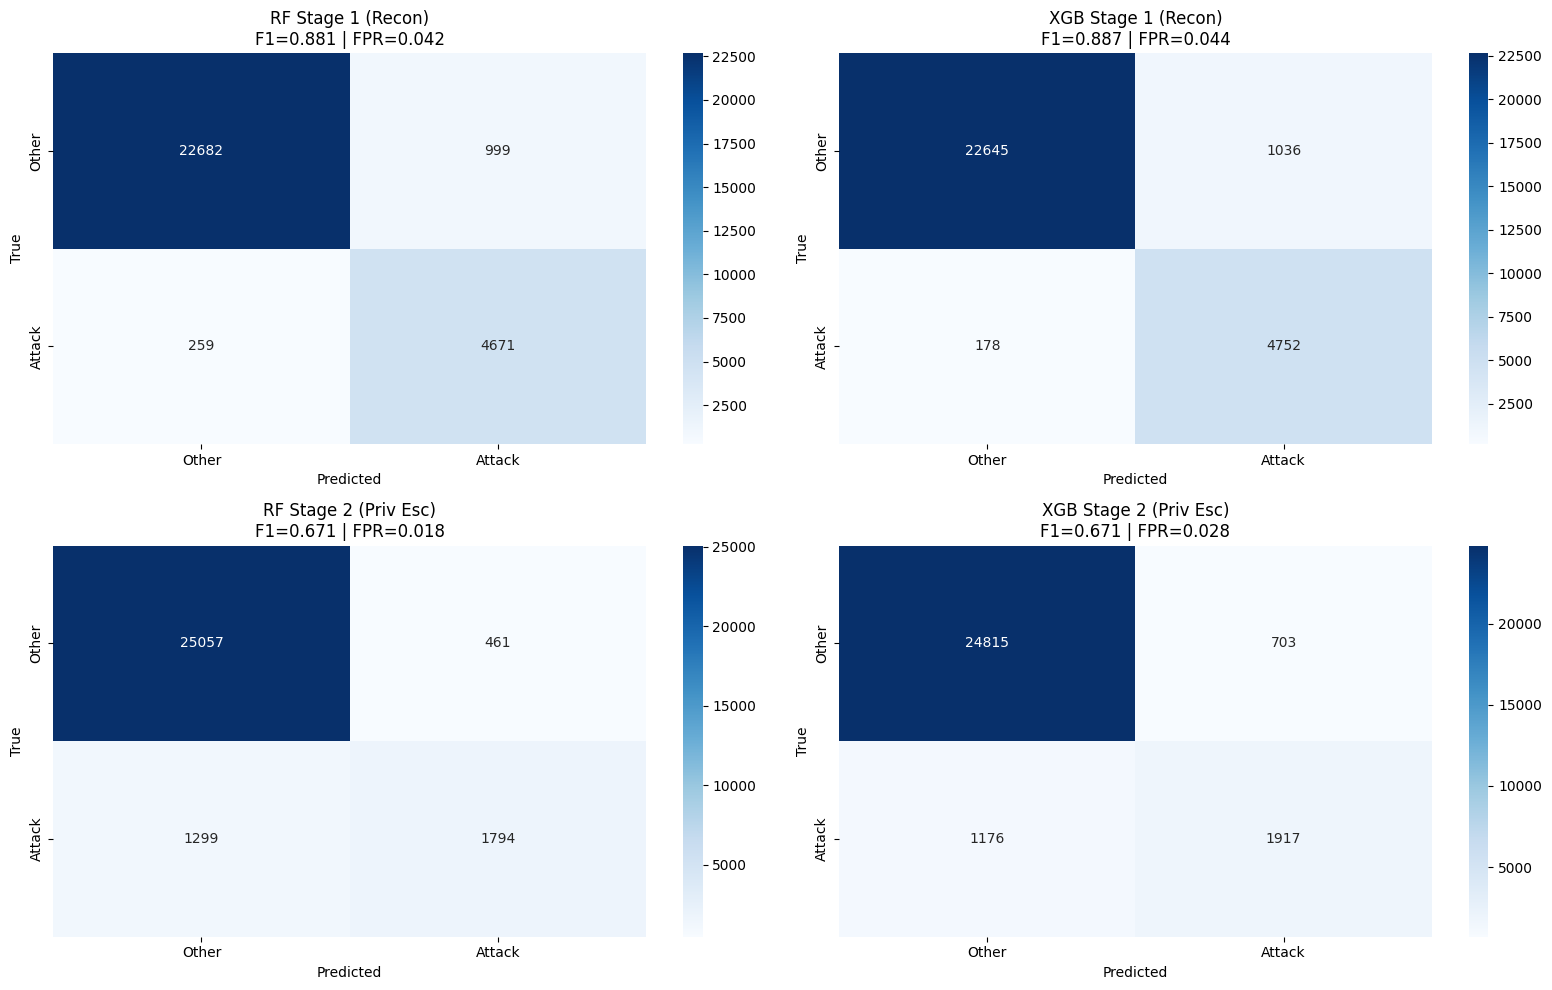

In [427]:
# ═══════════════════════════════════════════════════════════
# Confusion Matrices — Stage 1 & Stage 2 (RF vs XGB)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models_cm = [
    (axes[0,0], 'RF Stage 1 (Recon)',     rf_s1,  X_te1,     y_te1),
    (axes[0,1], 'XGB Stage 1 (Recon)',    xgb_s1, X_te1_xgb, y_te1),
    (axes[1,0], 'RF Stage 2 (Priv Esc)',  rf_s2,  X_te2,     y_te2),
    (axes[1,1], 'XGB Stage 2 (Priv Esc)', xgb_s2, X_te2_xgb, y_te2),
]

for ax, lbl, model, X_te, y_te in models_cm:
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    fpr = cm[0,1] / (cm[0,0] + cm[0,1])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Other', 'Attack'], yticklabels=['Other', 'Attack'])
    ax.set_title(f"{lbl}\nF1={f1:.3f} | FPR={fpr:.3f}")
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_v4.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

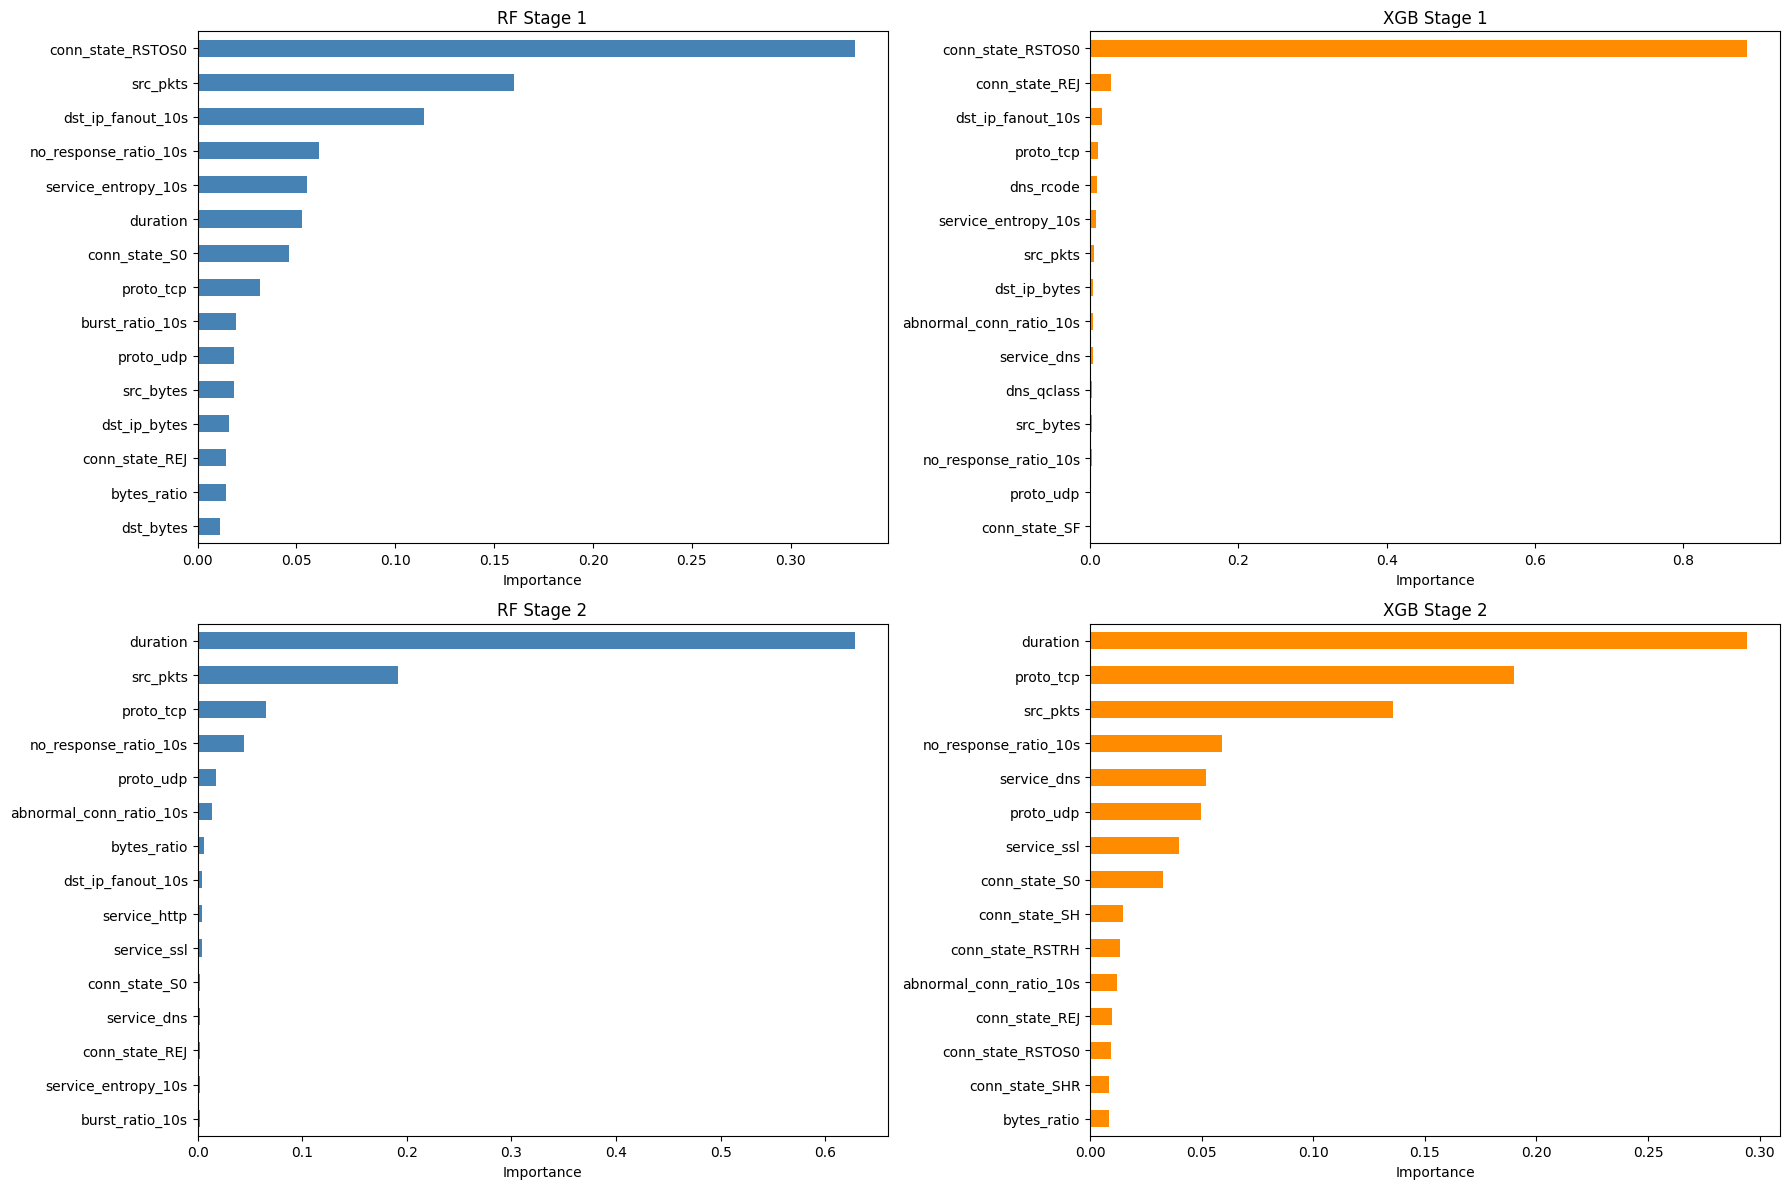

In [428]:
# ═══════════════════════════════════════════════════════════
# Feature Importance — Stage 1 & 2 (RF vs XGB)
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

models_fi = [
    (axes[0,0], 'RF Stage 1',  rf_s1,  X_tr1,     'steelblue'),
    (axes[0,1], 'XGB Stage 1', xgb_s1, X_tr1_xgb, 'darkorange'),
    (axes[1,0], 'RF Stage 2',  rf_s2,  X_tr2,     'steelblue'),
    (axes[1,1], 'XGB Stage 2', xgb_s2, X_tr2_xgb, 'darkorange'),
]

for ax, lbl, model, X_tr, color in models_fi:
    imp = pd.Series(model.feature_importances_, index=X_tr.columns).nlargest(15)
    imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(lbl)
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# PREDICTION SETUP
---

## 11. Dataset creation

### Stage aware

#### Entity-Level Feature Construction

##### General Aggregation

In [429]:
def aggregate_by_dst_ip(dftest, stage_num=3):
    # Aggregate by destination IP using actual columns
    agg_dict = {}

    # Identify numeric and categorical columns
    numeric_cols = []
    categorical_cols = []
    for col in dftest.columns:
        if col != 'dst_ip':
            if dftest[col].dtype in ['int64', 'float64'] and col != 'stage':
                numeric_cols.append(col)
                agg_dict[col] = ['sum', 'mean', 'min', 'max', 'std']
            elif col == 'stage':
                # For 'stage': 1 if this dst_ip ever appears at stage_num, else 0
                agg_dict[col] = lambda x: 1 if (x == stage_num).any() else 0
            else:
                categorical_cols.append(col)

    # First aggregation for numeric columns
    dftest_agg = dftest.groupby('dst_ip').agg(agg_dict)
    # one honest flow count per dst_ip (replaces the ~20 redundant *_count cols)
    dftest_agg['flow_count'] = dftest.groupby('dst_ip').size()

    # Flatten numeric column names (keep 'stage' as is)
    dftest_agg.columns = ['stage' if col[0] == 'stage' else '_'.join(col).strip()
                          for col in dftest_agg.columns.values]

    # Categorical (one-hot dummy) columns: emit ONE column per dummy.
    # The dummy is already 0/1, so count-of-1s is the only non-redundant value
    # (count-of-0s = flow_count - count-of-1s, already captured by flow_count).
    for cat_col in categorical_cols:
        col_int = dftest[cat_col].astype(int)              # local, no in-place mutation
        uniq = set(col_int.dropna().unique())
        if uniq.issubset({0, 1}):
            # binary dummy -> single count of present (==1)
            dftest_agg[f"{cat_col}_count"] = col_int.groupby(dftest['dst_ip']).sum()
        else:
            # genuine multi-value categorical -> keep per-value counts (no redundancy here)
            vc = col_int.groupby(dftest['dst_ip']).value_counts().unstack(fill_value=0)
            vc.columns = [f"{cat_col}_{val}_count" for val in vc.columns]
            dftest_agg = dftest_agg.join(vc)

    # Round numeric columns
    dftest_agg = dftest_agg.round(4)
    return dftest_agg

In [430]:
def build_stage3_dataset(df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
                         ef_raw_train=None, ef_raw_test=None):
  """Stage 3 dataset, stage-aware. Now joins entity features (ef_*) by dst_ip,
  bypassing aggregate_by_dst_ip. ef_raw_train/test come from Cell 26."""

  assert 'dst_ip' in df_test_past.columns, "dst_ip missing from df_test_past"
  assert 'dst_ip' in df_future.columns,    "dst_ip missing from df_future"

  NON_FEATURE_COLS = ['dst_ip', 'stage']
  def make_X(df, reference_cols):
      X = df.drop(columns=NON_FEATURE_COLS, errors='ignore')
      return X.reindex(columns=reference_cols, fill_value=0)

  test_past_enriched = df_test_past.copy()
  future_enriched    = df_future.copy()
  ref_cols_s1 = X_tr1.columns
  ref_cols_s2 = X_tr2.columns

  X_te_past_s1   = make_X(test_past_enriched, ref_cols_s1)
  X_te_past_s2   = make_X(test_past_enriched, ref_cols_s2)
  X_te_future_s1 = make_X(future_enriched,    ref_cols_s1)
  X_te_future_s2 = make_X(future_enriched,    ref_cols_s2)

  # 3. Attach probas
  test_past_enriched['stage_1_proba'] = pd.to_numeric(rf_s1.predict_proba(X_te_past_s1)[:, 1].astype(float), errors='coerce')
  test_past_enriched['stage_2_proba'] = pd.to_numeric(rf_s2.predict_proba(X_te_past_s2)[:, 1].astype(float), errors='coerce')
  future_enriched['stage_1_proba']    = pd.to_numeric(rf_s1.predict_proba(X_te_future_s1)[:, 1].astype(float), errors='coerce')
  future_enriched['stage_2_proba']    = pd.to_numeric(rf_s2.predict_proba(X_te_future_s2)[:, 1].astype(float), errors='coerce')

  # 3.5 NEW — proba-dependent entity features (Bucket B)
  ef_pb_train = entity_features_proba(test_past_enriched)
  ef_pb_test  = entity_features_proba(future_enriched)

  # 4. General aggregation (UNCHANGED)
  train_agg = aggregate_by_dst_ip(test_past_enriched, stage_num=3)
  test_agg  = aggregate_by_dst_ip(future_enriched,    stage_num=3)

  # 4.5 NEW — join entity features by dst_ip (bypasses aggregate_by_dst_ip)
  if ef_raw_train is not None:
      train_agg = train_agg.join(ef_raw_train)
      test_agg  = test_agg.join(ef_raw_test)
  train_agg = train_agg.join(ef_pb_train)
  test_agg  = test_agg.join(ef_pb_test)
  ef_cols = [c for c in train_agg.columns if c.startswith('ef_')]
  train_agg[ef_cols] = train_agg[ef_cols].fillna(0.0)
  test_agg[[c for c in test_agg.columns if c.startswith('ef_')]] = \
      test_agg.filter(like='ef_').fillna(0.0)

  print(f"\nStage 3 train_agg shape  : {train_agg.shape}  (one row per dst_ip)")
  print(f"Stage 3 test_agg shape   : {test_agg.shape}")
  print(f"Entity features added    : {len(ef_cols)}")
  print(f"Positive labels in train : {train_agg['stage'].sum()}")
  print(f"Positive labels in test  : {test_agg['stage'].sum()}")

  # 5. Align columns (train reference, test fills missing with 0)
  label_col = 'stage'
  train_cols = [c for c in train_agg.columns if c != label_col]
  test_agg  = test_agg.reindex(columns=train_cols + [label_col], fill_value=0)
  train_agg = train_agg.reindex(columns=train_cols + [label_col], fill_value=0)

  return train_agg, test_agg

### Direct Predictions

In [431]:
def build_stage3_dataset_baseline(df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
                                  ef_raw_train=None, ef_raw_test=None):
  """Stage 3 baseline: general aggregation + raw entity features only (no probas)."""
  assert 'dst_ip' in df_test_past.columns
  assert 'dst_ip' in df_future.columns

  train_agg = aggregate_by_dst_ip(df_test_past.copy(), stage_num=3)
  test_agg  = aggregate_by_dst_ip(df_future.copy(),    stage_num=3)

  if ef_raw_train is not None:
      train_agg = train_agg.join(ef_raw_train)
      test_agg  = test_agg.join(ef_raw_test)
      ef_cols = [c for c in train_agg.columns if c.startswith('ef_')]
      train_agg[ef_cols] = train_agg[ef_cols].fillna(0.0)
      test_agg[[c for c in test_agg.columns if c.startswith('ef_')]] = \
          test_agg.filter(like='ef_').fillna(0.0)

  print(f"\nStage 3 baseline train_agg : {train_agg.shape}")
  print(f"Stage 3 baseline test_agg  : {test_agg.shape}")
  print(f"Positive labels in train   : {train_agg['stage'].sum()}")
  print(f"Positive labels in test    : {test_agg['stage'].sum()}")

  label_col = 'stage'
  train_cols = [c for c in train_agg.columns if c != label_col]
  test_agg  = test_agg.reindex(columns=train_cols + [label_col], fill_value=0)
  train_agg = train_agg.reindex(columns=train_cols + [label_col], fill_value=0)
  return train_agg, test_agg

In [432]:
def prepare_Xy_pred(train_data = df_test_past, test_data = df_future, stage_num = 3):
    y_train = train_data['stage'].astype(int)  #Output: Binary for a specific attack stage ("stage_num")
    y_test = test_data['stage'].astype(int)
    drop = 'stage'
    X_train = train_data.drop(columns=drop, errors='ignore')
    X_test = test_data.drop(columns=drop, errors='ignore')

    return X_train, X_test, y_train, y_test

#### Call Function

In [433]:
# Cell 58 — stage-aware
train_agg, test_agg = build_stage3_dataset(
    df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
    ef_raw_train=ef_raw_train, ef_raw_test=ef_raw_test)
X_tr3, X_te3, y_tr3, y_te3 = prepare_Xy_pred(train_agg, test_agg, stage_num=3)
print(f"\nX_tr3: {X_tr3.shape} | y_tr3 positives: {y_tr3.sum()}")
print(f"X_te3: {X_te3.shape} | y_te3 positives: {y_te3.sum()}")
print("Stage 3 features (stage-aware):")
for col in X_tr3.columns:
    print(col)

# Cell 59 — baseline
train_agg_base, test_agg_base = build_stage3_dataset_baseline(
    df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2,
    ef_raw_train=ef_raw_train, ef_raw_test=ef_raw_test)
X_tr3_base, X_te3_base, y_tr3_base, y_te3_base = prepare_Xy_pred(train_agg_base, test_agg_base, stage_num=3)
print(f"\nX_tr3_base: {X_tr3_base.shape} | y_tr3_base positives: {y_tr3_base.sum()}")
print(f"X_te3_base: {X_te3_base.shape} | y_te3_base positives: {y_te3_base.sum()}")
print("Stage 3 features (baseline):")
for col in X_tr3_base.columns:
    print(col)



Stage 3 train_agg shape  : (376, 118)  (one row per dst_ip)
Stage 3 test_agg shape   : (102, 118)
Entity features added    : 3
Positive labels in train : 13
Positive labels in test  : 13

X_tr3: (376, 117) | y_tr3 positives: 13
X_te3: (102, 117) | y_te3 positives: 13
Stage 3 features (stage-aware):
duration_sum
duration_mean
duration_min
duration_max
duration_std
src_bytes_sum
src_bytes_mean
src_bytes_min
src_bytes_max
src_bytes_std
dst_bytes_sum
dst_bytes_mean
dst_bytes_min
dst_bytes_max
dst_bytes_std
missed_bytes_sum
missed_bytes_mean
missed_bytes_min
missed_bytes_max
missed_bytes_std
src_pkts_sum
src_pkts_mean
src_pkts_min
src_pkts_max
src_pkts_std
dst_pkts_sum
dst_pkts_mean
dst_pkts_min
dst_pkts_max
dst_pkts_std
dst_ip_bytes_sum
dst_ip_bytes_mean
dst_ip_bytes_min
dst_ip_bytes_max
dst_ip_bytes_std
dns_qclass_sum
dns_qclass_mean
dns_qclass_min
dns_qclass_max
dns_qclass_std
dns_qtype_sum
dns_qtype_mean
dns_qtype_min
dns_qtype_max
dns_qtype_std
dns_rcode_sum
dns_rcode_mean
dns_rcode_m

# STAGE 3 PREDICTIONS

feat. hyperparameter and threshold tuning

## Stage aware

X_tr3: (376, 117)  |  y_tr3 positives: 13 / 376
X_te3: (102, 117)  |  y_te3 positives: 13 / 102

Class ratio (neg:pos) in train = 27.9:1

Running RandomizedSearchCV (40 iterations × 5-fold CV)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV F1  : 0.3100
Best params : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': {0: 1, 1: 41}}

Optimal threshold: 0.5276  (F1=0.8000)

Stage 3 — default threshold (0.50)
F1=0.7692  Prec=0.7692  Rec=0.7692  FPR=0.0337
TN=86  FP=3  FN=3  TP=10
              precision    recall  f1-score   support

 Safe entity       0.97      0.97      0.97        89
Under threat       0.77      0.77      0.77        13

    accuracy                           0.94       102
   macro avg       0.87      0.87      0.87       102
weighted avg       0.94      0.94      0.94       102


Stage 3 — optimal threshold (0.5276)
F1=0.8000  Prec=0.8333  Rec=0.7692  FPR=0.0225
TN=87

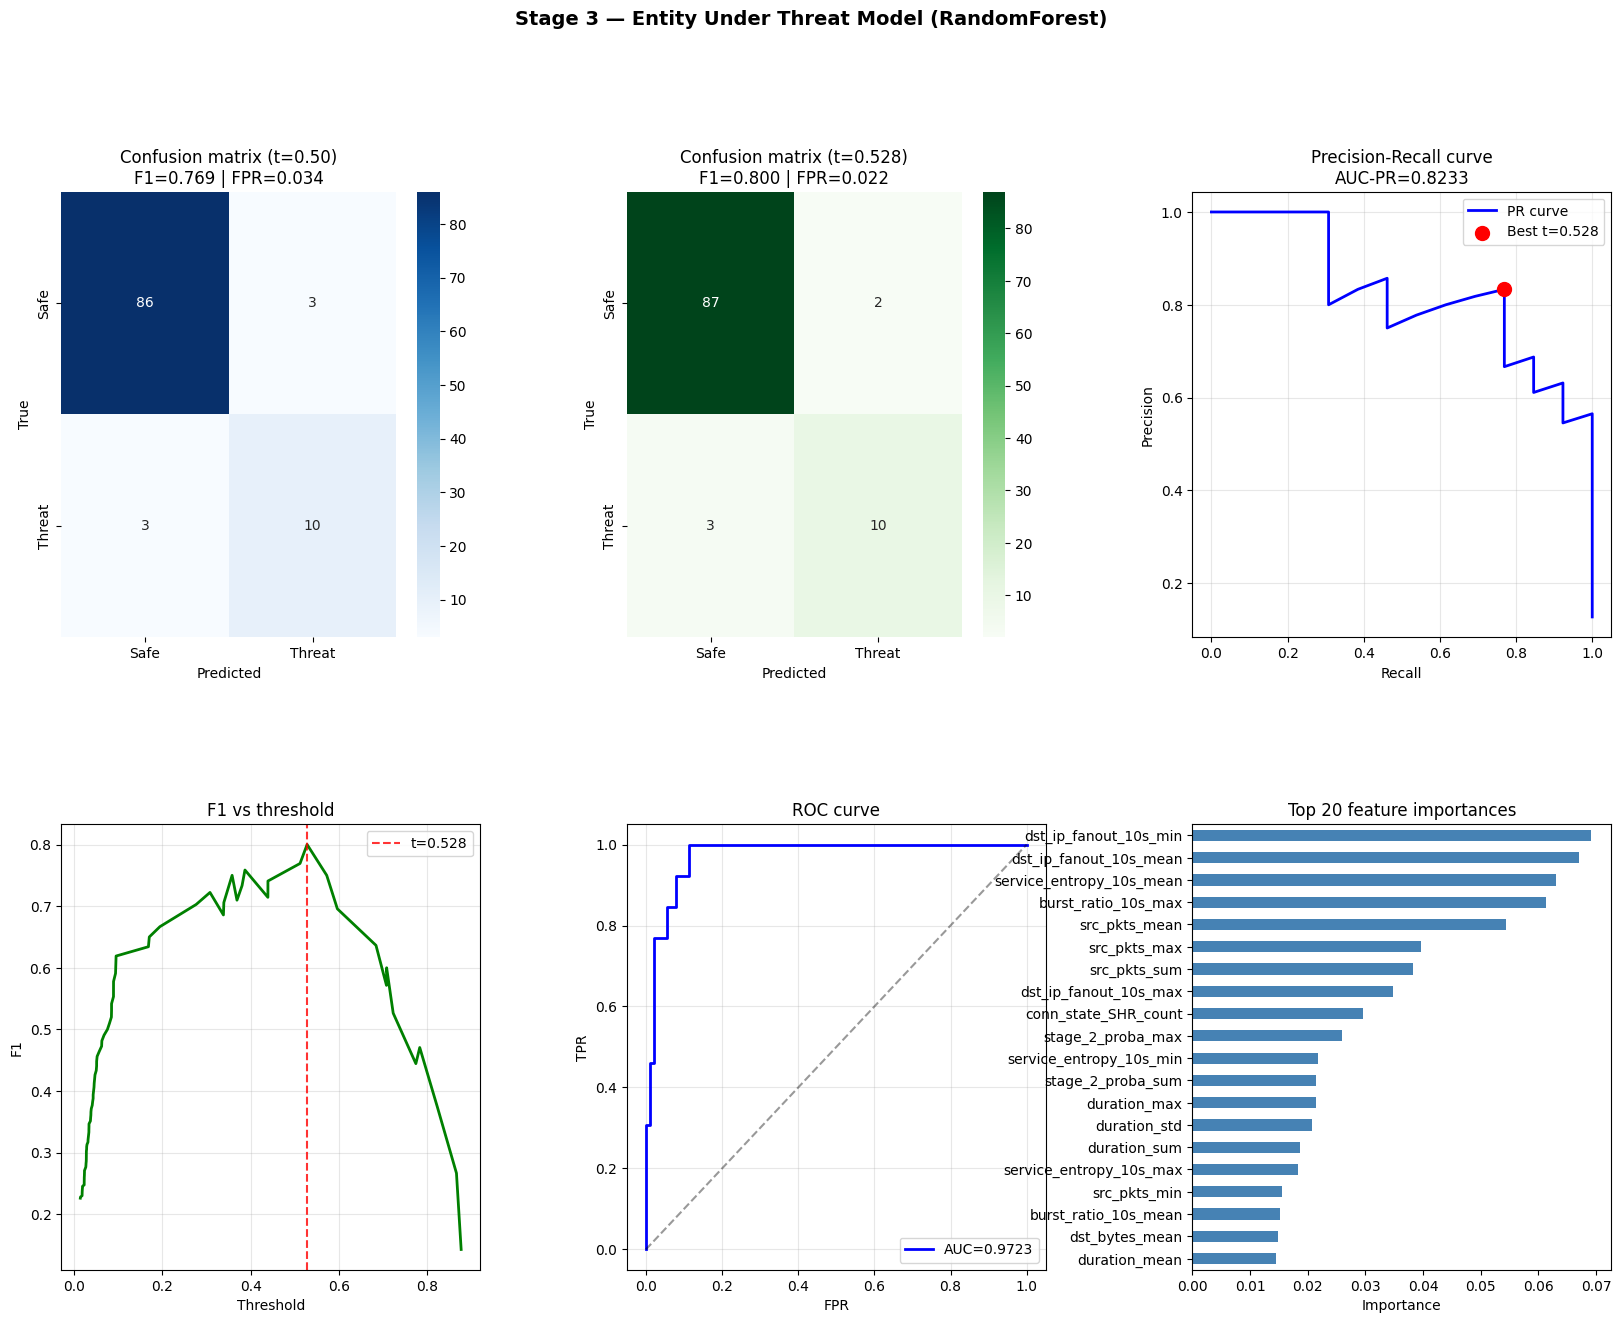


STAGE 3 SUMMARY
  Best hyperparams : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': {0: 1, 1: 41}}
  CV F1 (train)    : 0.3100
  Test F1 (t=0.50) : 0.7692
  Test F1 (t=0.528) : 0.8000
  AUC-ROC          : 0.9723
  AUC-PR           : 0.8233
  Test entities    : 102 | Threat: 13 | Safe: 89


In [434]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — ENTITY UNDER THREAT MODEL (RandomForest + RandomizedSearchCV)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, auc,
                             precision_recall_fscore_support)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns   
import numpy as np

# ── 1. Sanity check ───────────────────────────────────────────────────────────
print(f"X_tr3: {X_tr3.shape}  |  y_tr3 positives: {int(y_tr3.sum())} / {len(y_tr3)}")
print(f"X_te3: {X_te3.shape}  |  y_te3 positives: {int(y_te3.sum())} / {len(y_te3)}")
assert y_tr3.sum() > 0, "No positives in training — check prepare_Xy_pred fix"
assert y_te3.sum() > 0, "No positives in test — check prepare_Xy_pred fix"

# ── 2. Class imbalance ratio (used for scale_pos_weight guidance) ─────────────
neg_tr, pos_tr = (y_tr3 == 0).sum(), (y_tr3 == 1).sum()
imbalance_ratio = neg_tr / pos_tr
print(f"\nClass ratio (neg:pos) in train = {imbalance_ratio:.1f}:1")

# ── 3. Hyperparameter search space ───────────────────────────────────────────
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'class_weight'     : ['balanced', 'balanced_subsample',
                          {0: 1, 1: int(imbalance_ratio)},
                          {0: 1, 1: int(imbalance_ratio * 1.5)}],
}

# Stratified CV — critical for imbalanced entity-level data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',          # optimise for minority-class F1
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print("\nRunning RandomizedSearchCV (40 iterations × 5-fold CV)...")
search.fit(X_tr3, y_tr3)

print(f"\nBest CV F1  : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")

rf_s3 = search.best_estimator_

# ── 4. Default threshold predictions ──────────────────────────────────────────
y_proba_s3 = rf_s3.predict_proba(X_te3)[:, 1]
y_pred_s3  = rf_s3.predict(X_te3)

# ── 5. Optimal threshold via PR curve ────────────────────────────────────────
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te3, y_proba_s3)
f1_arr  = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-8)
best_idx   = np.argmax(f1_arr)
best_thresh = thresh_arr[best_idx] if best_idx < len(thresh_arr) else 0.5

print(f"\nOptimal threshold: {best_thresh:.4f}  (F1={f1_arr[best_idx]:.4f})")
y_pred_opt = (y_proba_s3 >= best_thresh).astype(int)

# ── 6. Evaluation helper (reuses notebook style) ─────────────────────────────
def eval_s3(y_true, y_pred, label):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(classification_report(y_true, y_pred,
          target_names=['Safe entity', 'Under threat'], zero_division=0))
    return {'f1': f1, 'precision': prec, 'recall': rec, 'fpr': fpr, 'cm': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

results_s3_default = eval_s3(y_te3, y_pred_s3,  "Stage 3 — default threshold (0.50)")
results_s3_opt     = eval_s3(y_te3, y_pred_opt,  f"Stage 3 — optimal threshold ({best_thresh:.4f})")

# ── 7. Figures ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 7a. Confusion matrix — default threshold
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(results_s3_default['cm'], annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax1.set_title(f"Confusion matrix (t=0.50)\nF1={results_s3_default['f1']:.3f} | FPR={results_s3_default['fpr']:.3f}")
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

# 7b. Confusion matrix — optimal threshold
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(results_s3_opt['cm'], annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax2.set_title(f"Confusion matrix (t={best_thresh:.3f})\nF1={results_s3_opt['f1']:.3f} | FPR={results_s3_opt['fpr']:.3f}")
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

# 7c. PR curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(rec_arr, prec_arr, 'b-', lw=2, label='PR curve')
ax3.scatter(rec_arr[best_idx], prec_arr[best_idx],
            color='red', s=100, zorder=5, label=f'Best t={best_thresh:.3f}')
pr_auc = auc(rec_arr, prec_arr)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall curve\nAUC-PR={pr_auc:.4f}')
ax3.legend(); ax3.grid(True, alpha=0.3)

# 7d. F1 vs threshold
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(thresh_arr, f1_arr[:-1], 'g-', lw=2)
ax4.axvline(x=best_thresh, color='r', ls='--', alpha=0.8, label=f't={best_thresh:.3f}')
ax4.set_xlabel('Threshold'); ax4.set_ylabel('F1')
ax4.set_title('F1 vs threshold'); ax4.legend(); ax4.grid(True, alpha=0.3)

# 7e. ROC curve
fpr_roc, tpr_roc, _ = roc_curve(y_te3, y_proba_s3)
roc_auc_score = auc(fpr_roc, tpr_roc)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fpr_roc, tpr_roc, 'b-', lw=2, label=f'AUC={roc_auc_score:.4f}')
ax5.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.set_title('ROC curve'); ax5.legend(); ax5.grid(True, alpha=0.3)

# 7f. Feature importance (top 20)
ax6 = fig.add_subplot(gs[1, 2])
feat_imp = pd.Series(rf_s3.feature_importances_, index=X_tr3.columns).nlargest(20)
feat_imp.plot(kind='barh', ax=ax6, color='steelblue')
ax6.set_title('Top 20 feature importances')
ax6.set_xlabel('Importance'); ax6.invert_yaxis()

plt.suptitle('Stage 3 — Entity Under Threat Model (RandomForest)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('stage3_entity_underthreat_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Summary ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STAGE 3 SUMMARY")
print("="*60)
print(f"  Best hyperparams : {search.best_params_}")
print(f"  CV F1 (train)    : {search.best_score_:.4f}")
print(f"  Test F1 (t=0.50) : {results_s3_default['f1']:.4f}")
print(f"  Test F1 (t={best_thresh:.3f}) : {results_s3_opt['f1']:.4f}")
print(f"  AUC-ROC          : {roc_auc_score:.4f}")
print(f"  AUC-PR           : {pr_auc:.4f}")
print(f"  Test entities    : {len(y_te3)} | Threat: {int(y_te3.sum())} | Safe: {int((y_te3==0).sum())}")


## Direct/Baseline


X_tr3_base: (376, 106)  |  y_tr3_base positives: 13 / 376
X_te3_base: (102, 106)  |  y_te3_base positives: 13 / 102

Class ratio (neg:pos) in train = 27.9:1

Running RandomizedSearchCV (40 iterations × 5-fold CV)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV F1  : 0.3333
Best params : {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': {0: 1, 1: 41}}

Optimal threshold: 0.4209  (F1=0.8000)

Stage 3 — default threshold (0.50)
F1=0.7200  Prec=0.7500  Rec=0.6923  FPR=0.0337
TN=86  FP=3  FN=4  TP=9
              precision    recall  f1-score   support

 Safe entity       0.96      0.97      0.96        89
Under threat       0.75      0.69      0.72        13

    accuracy                           0.93       102
   macro avg       0.85      0.83      0.84       102
weighted avg       0.93      0.93      0.93       102


Stage 3 — optimal threshold (0.4209)
F1=0.8000  Prec=0.7059  Rec=0.923

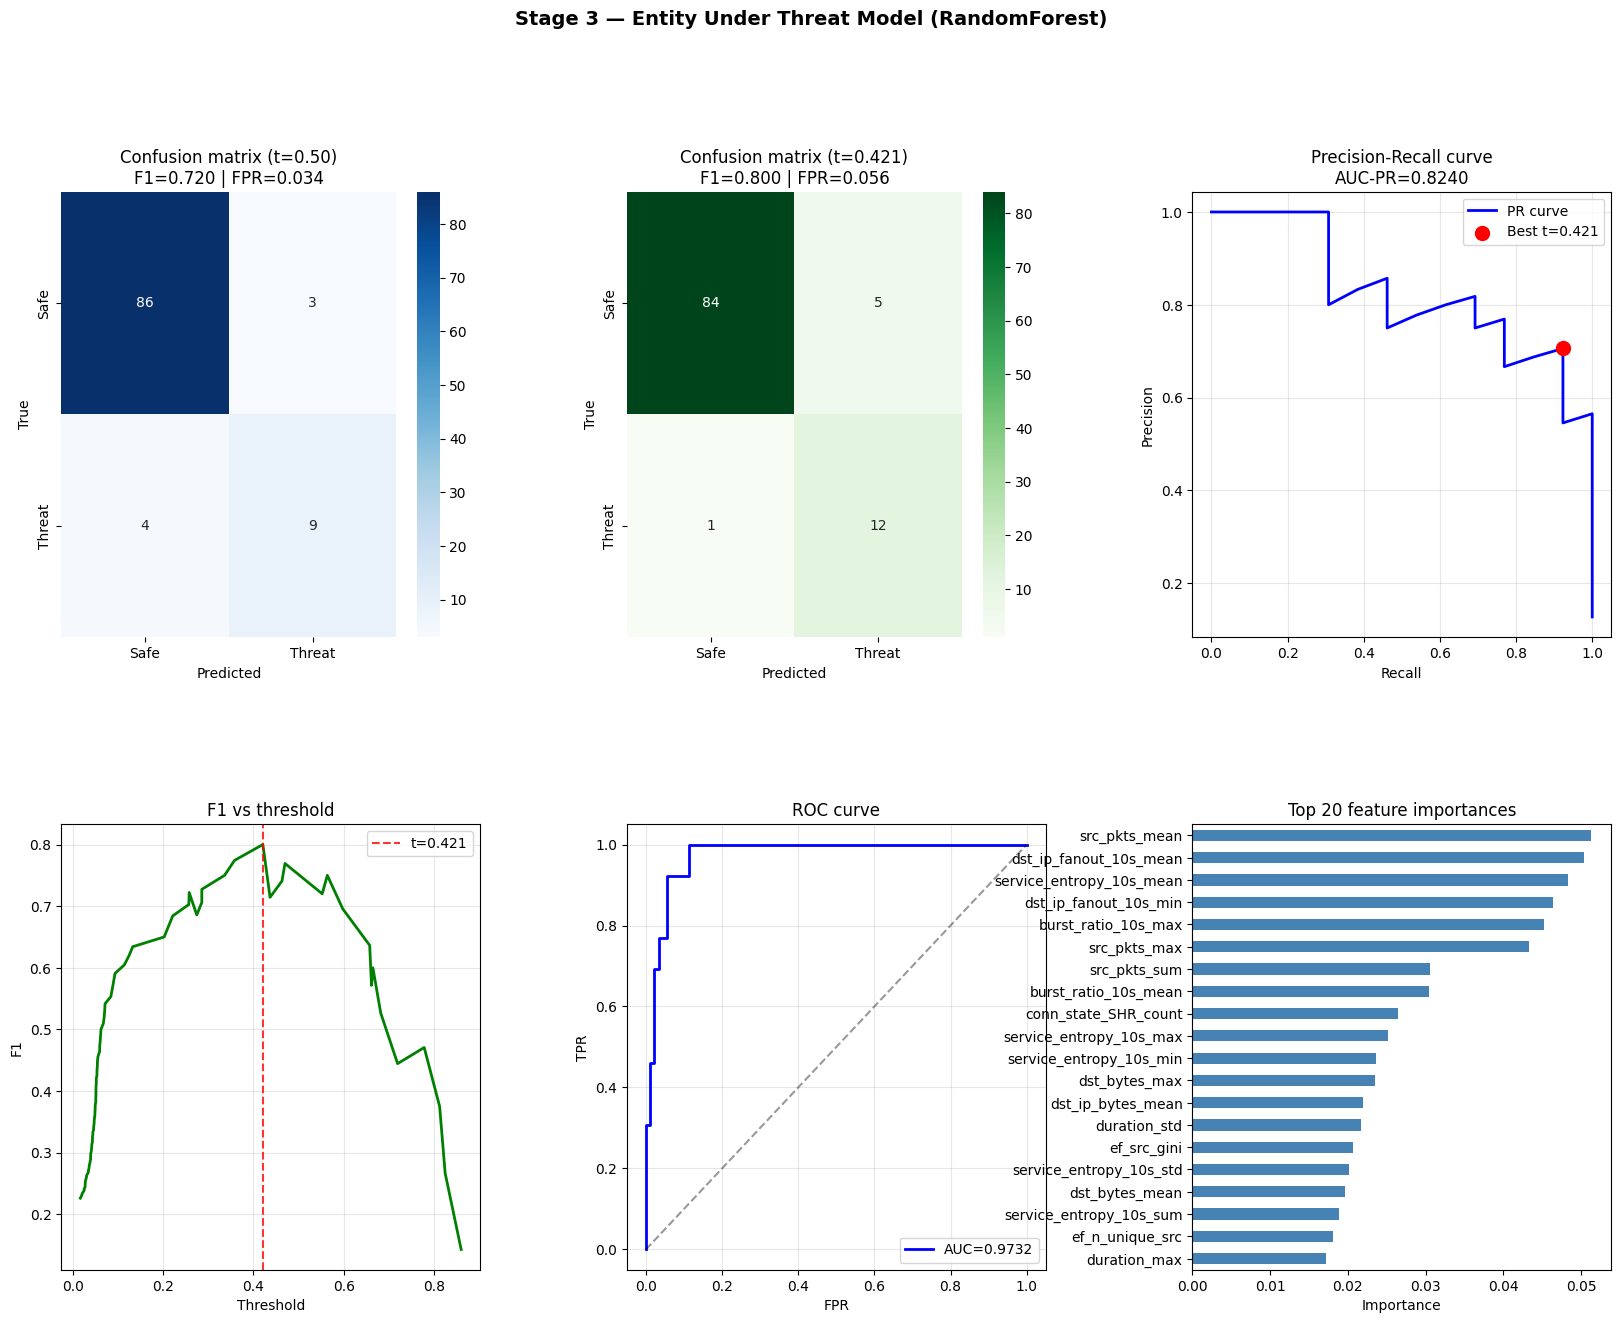


STAGE 3 SUMMARY
  Best hyperparams : {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': {0: 1, 1: 41}}
  CV F1 (train)    : 0.3333
  Test F1 (t=0.50) : 0.7200
  Test F1 (t=0.421) : 0.8000
  AUC-ROC          : 0.9732
  AUC-PR           : 0.8240
  Test entities    : 102 | Threat: 13 | Safe: 89


In [435]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — ENTITY UNDER THREAT MODEL (RandomForest + RandomizedSearchCV)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, auc,
                             precision_recall_fscore_support)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns   
import numpy as np

# ── 1. Sanity check ───────────────────────────────────────────────────────────
print(f"X_tr3_base: {X_tr3_base.shape}  |  y_tr3_base positives: {int(y_tr3_base.sum())} / {len(y_tr3_base)}")
print(f"X_te3_base: {X_te3_base.shape}  |  y_te3_base positives: {int(y_te3_base.sum())} / {len(y_te3_base)}")
assert y_tr3_base.sum() > 0, "No positives in training — check prepare_Xy_pred fix"
assert y_te3_base.sum() > 0, "No positives in test — check prepare_Xy_pred fix"

# ── 2. Class imbalance ratio (used for scale_pos_weight guidance) ─────────────
neg_tr, pos_tr = (y_tr3_base == 0).sum(), (y_tr3_base == 1).sum()
imbalance_ratio = neg_tr / pos_tr
print(f"\nClass ratio (neg:pos) in train = {imbalance_ratio:.1f}:1")

# ── 3. Hyperparameter search space ───────────────────────────────────────────
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'class_weight'     : ['balanced', 'balanced_subsample',
                          {0: 1, 1: int(imbalance_ratio)},
                          {0: 1, 1: int(imbalance_ratio * 1.5)}],
}

# Stratified CV — critical for imbalanced entity-level data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',          # optimise for minority-class F1
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print("\nRunning RandomizedSearchCV (40 iterations × 5-fold CV)...")
search.fit(X_tr3_base, y_tr3_base)

print(f"\nBest CV F1  : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")

rf_s3 = search.best_estimator_

# ── 4. Default threshold predictions ──────────────────────────────────────────
y_proba_s3_base = rf_s3.predict_proba(X_te3_base)[:, 1]
y_pred_s3_base  = rf_s3.predict(X_te3_base)

# ── 5. Optimal threshold via PR curve ────────────────────────────────────────
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te3_base, y_proba_s3_base)
f1_arr  = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-8)
best_idx   = np.argmax(f1_arr)
best_thresh = thresh_arr[best_idx] if best_idx < len(thresh_arr) else 0.5

print(f"\nOptimal threshold: {best_thresh:.4f}  (F1={f1_arr[best_idx]:.4f})")
y_pred_s3_opt_base = (y_proba_s3_base >= best_thresh).astype(int)

# ── 6. Evaluation helper (reuses notebook style) ─────────────────────────────
def eval_s3(y_true, y_pred, label):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(classification_report(y_true, y_pred,
          target_names=['Safe entity', 'Under threat'], zero_division=0))
    return {'f1': f1, 'precision': prec, 'recall': rec, 'fpr': fpr, 'cm': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

results_s3_default_base = eval_s3(y_te3_base, y_pred_s3_base,  "Stage 3 — default threshold (0.50)")
results_s3_opt_base     = eval_s3(y_te3_base, y_pred_s3_opt_base,  f"Stage 3 — optimal threshold ({best_thresh:.4f})")

# ── 7. Figures ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 7a. Confusion matrix — default threshold
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(results_s3_default_base['cm'], annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax1.set_title(f"Confusion matrix (t=0.50)\nF1={results_s3_default_base['f1']:.3f} | FPR={results_s3_default_base['fpr']:.3f}")
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

# 7b. Confusion matrix — optimal threshold
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(results_s3_opt_base['cm'], annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax2.set_title(f"Confusion matrix (t={best_thresh:.3f})\nF1={results_s3_opt_base['f1']:.3f} | FPR={results_s3_opt_base['fpr']:.3f}")
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

# 7c. PR curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(rec_arr, prec_arr, 'b-', lw=2, label='PR curve')
ax3.scatter(rec_arr[best_idx], prec_arr[best_idx],
            color='red', s=100, zorder=5, label=f'Best t={best_thresh:.3f}')
pr_auc = auc(rec_arr, prec_arr)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall curve\nAUC-PR={pr_auc:.4f}')
ax3.legend(); ax3.grid(True, alpha=0.3)

# 7d. F1 vs threshold
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(thresh_arr, f1_arr[:-1], 'g-', lw=2)
ax4.axvline(x=best_thresh, color='r', ls='--', alpha=0.8, label=f't={best_thresh:.3f}')
ax4.set_xlabel('Threshold'); ax4.set_ylabel('F1')
ax4.set_title('F1 vs threshold'); ax4.legend(); ax4.grid(True, alpha=0.3)

# 7e. ROC curve
fpr_roc, tpr_roc, _ = roc_curve(y_te3_base, y_proba_s3_base)
roc_auc_score = auc(fpr_roc, tpr_roc)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fpr_roc, tpr_roc, 'b-', lw=2, label=f'AUC={roc_auc_score:.4f}')
ax5.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.set_title('ROC curve'); ax5.legend(); ax5.grid(True, alpha=0.3)

# 7f. Feature importance (top 20)
ax6 = fig.add_subplot(gs[1, 2])
feat_imp = pd.Series(rf_s3.feature_importances_, index=X_tr3_base.columns).nlargest(20)
feat_imp.plot(kind='barh', ax=ax6, color='steelblue')
ax6.set_title('Top 20 feature importances')
ax6.set_xlabel('Importance'); ax6.invert_yaxis()

plt.suptitle('Stage 3 — Entity Under Threat Model (RandomForest)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('stage3_entity_underthreat_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Summary ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STAGE 3 SUMMARY")
print("="*60)
print(f"  Best hyperparams : {search.best_params_}")
print(f"  CV F1 (train)    : {search.best_score_:.4f}")
print(f"  Test F1 (t=0.50) : {results_s3_default_base['f1']:.4f}")
print(f"  Test F1 (t={best_thresh:.3f}) : {results_s3_opt_base['f1']:.4f}")
print(f"  AUC-ROC          : {roc_auc_score:.4f}")
print(f"  AUC-PR           : {pr_auc:.4f}")
print(f"  Test entities    : {len(y_te3_base)} | Threat: {int(y_te3_base.sum())} | Safe: {int((y_te3_base==0).sum())}")
